In [20]:
#import required classes and packages
import QANN  #loading Qiskit QANN model for quantum features extraction
from skimage.metrics import structural_similarity as ssim #function to calculate SSIM
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import numpy as np
from keras.utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization, AveragePooling2D, Input, Conv2D, UpSampling2D
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from math import log10, sqrt
import keras
import warnings
warnings.filterwarnings('ignore')

In [32]:
#function to calculate SSIM between original and decoded or compress image 
def imageSSIM(original, predict):
    original_image = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    predict_image = cv2.cvtColor(predict, cv2.COLOR_BGR2GRAY)
    ssim_value = ssim(original_image, predict_image, data_range = predict_image.max() - predict_image.min())
    return round(ssim_value, 2)

In [33]:
#function to calculate PSNR between original and  decoded or compress image 
def PSNR(original, predict):
    max_value = 255
    mse = np.mean((original - predict) ** 2) 
    if(mse == 0):
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_value / sqrt(mse)) 
    return round(psnr/100,2), mse

In [4]:
#defining and loading QANN model object to exract features
qann = QANN.loadQANN()
print("QISKIT QANN Features Extraction Model Loaded")

QISKIT QANN Features Extraction Model Loaded


In [5]:
#function to load covid chest x-ray dataset
if os.path.exists('model/X.npy'): #if dataset already processed then load it
    X = np.load('model/X.npy')
    Y = np.load('model/Y.npy')
else: #if not processed then read and process all image processing
    for root, dirs, directory in os.walk("Dataset"): #loop and read each image from dataset
        for j in range(len(directory)):
            qann_features = QANN.getQANNFeatures(root+"/"+directory[j], qann) #get compress features image using QANN
            img = cv2.imread(root+"/"+directory[j])
            img = cv2.resize(img, (128, 128), cv2.INTER_LANCZOS4)#resize image
            X.append(qann_features)#add compress features and its target image to X and Y training array
            Y.append(img)
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save('model/X',X)
    np.save('model/Y',Y)
print("Covid Chest X-Ray Images Loaded")
print("Total images available in dataset= "+str(X.shape[0]))

Covid Chest X-Ray Images Loaded
Total images available in dataset= 900


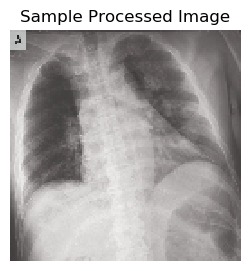

In [6]:
#display sample laoded and processed image
img = Y[0]
plt.figure(figsize=(4, 3))
plt.imshow(img)
plt.title("Sample Processed Image")
plt.axis('off')
plt.show()

In [7]:
#image preprocessing such as shuffling and normalization
X = X.astype('float32') #normalize images
X = X/255
Y = Y.astype('float32')
Y = Y/255
indices = np.arange(X.shape[0])
np.random.shuffle(indices) #shuffle images
X = X[indices]
Y = Y[indices]
print("Images preprocessing completed")

Images preprocessing completed


In [8]:
#split images into train and test for encoder and decoder training
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) #split dataset into train and test
print("80% images used to train encoder algorithm : "+str(X_train.shape[0]))
print("20% images used to test encoder algorithm : "+str(X_test.shape[0]))

80% images used to train encoder algorithm : 720
20% images used to test encoder algorithm : 180


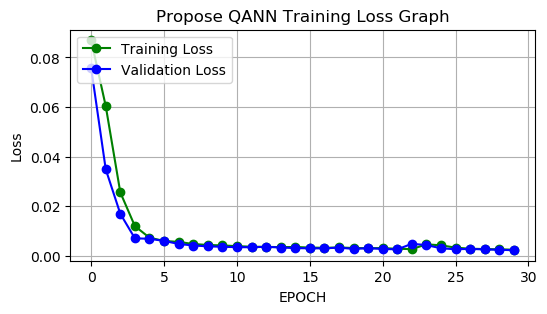

In [9]:
#defining classical neural network to train medical image compress model using QANN features
input_img = Input(shape=(128, 128, 3))
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
qann_input = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(qann_input)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
qann_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
qann_model = Model(input_img, qann_output)
qann_model.compile(optimizer='adam', loss='mean_squared_error')
if os.path.exists("model/qann_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/qann_weights.hdf5', verbose = 1, save_best_only = True)
    hist = qann_model.fit(X_train, y_train, batch_size = 64, epochs = 40, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/qann_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    qann_model.load_weights("model/qann_weights.hdf5")
f = open('model/qann_history.pckl', 'rb')
train_values = pickle.load(f)
f.close()
plt.figure(figsize=(6, 3))
plt.grid(True)
plt.xlabel('EPOCH')
plt.ylabel('Loss')
plt.plot(train_values['loss'], 'ro-', color = 'green')
plt.plot(train_values['val_loss'], 'ro-', color = 'blue')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper left')
plt.title('Propose QANN Training Loss Graph')
plt.show()    

In [61]:
#displaying X-Ray Image size and Space analysis
import pandas as pd
original_image = cv2.imread("Dataset/001.jpeg")
original_image = cv2.resize(original_image, (128, 128))
dcae_param = [int(cv2.IMWRITE_JPEG_QUALITY), 99]
cv2.imwrite('test.jpg', original_image, dcae_param)
original_size = os.path.getsize("Dataset/001.jpeg")
dcae_size = os.path.getsize("test.jpg")
qann_compress = QANN.getQANNFeatures("Dataset/001.jpeg", qann)
cv2.imwrite('test.jpg', qann_compress)
qann_compress_size = os.path.getsize("test.jpg")
output = []
output.append([original_size, dcae_size, qann_compress_size])
output.append(['Space Saving %',round(((original_size/1.12 - dcae_size) / original_size/1.12),2), round(((original_size/1.12 - qann_compress_size) / original_size/1.12),2)])
size = pd.DataFrame(output, columns=['Original Storage Size', 'Existing DCAE Compression Size', 'Propose QANN Compression Size'])
size

,Original Storage Size,Existing DCAE Compression Size,Propose QANN Compression Size
0,123144,11426.00,6580.00
1,Space Saving %,0.71,0.75


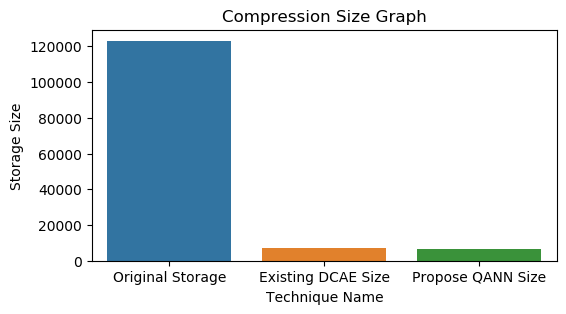

In [15]:
#storage size comparison graph
height = [original_size, dcae_size, qann_compress_size]
bars = ['Original Storage', 'Existing DCAE Size', 'Propose QANN Size']
plt.figure(figsize=(6, 3))
sns.barplot(x=bars, y=height)
plt.xlabel("Technique Name")
plt.ylabel("Storage Size")
plt.title("Compression Size Graph")
plt.show()

In [34]:
original_image = cv2.imread("testImages/2.png")
original_image = cv2.resize(original_image, (128, 128))
dcae_param = [int(cv2.IMWRITE_JPEG_QUALITY), 3]
cv2.imwrite('test.jpg', original_image, dcae_param)
dcae_image = cv2.imread("test.jpg")
dcae_ssim_value = imageSSIM(original_image, dcae_image)#calculate SSIM
dcae_psnr, dcae_mse = PSNR(original_image, dcae_image)#calculatee PSNR
qann_compress = QANN.getQANNFeatures("testImages/2.png", qann)
temp = []
temp.append(qann_compress)
test = np.asarray(temp)
test = test.astype('float32')
test = test/255
predict = qann_model.predict(test)#applying global autoencoder model to decompress image
predict = predict[0]#get predicted decompress image
qann_ssim_value = imageSSIM(original_image, predict*255)#calculate SSIM
qann_psnr, qann_mse = PSNR(original_image, predict*255)#calculatee PSNR
output = []
output.append(["Existing DCAE", dcae_ssim_value, dcae_psnr])
output.append(["Propose QANN Model", qann_ssim_value, qann_psnr])
output = pd.DataFrame(output, columns=['Algorithm Names', 'SSIM', 'PSNR'])
output

,Algorithm Names,SSIM,PSNR
0,Existing DCAE,0.61,0.30
1,Propose QANN Model,0.77,0.29


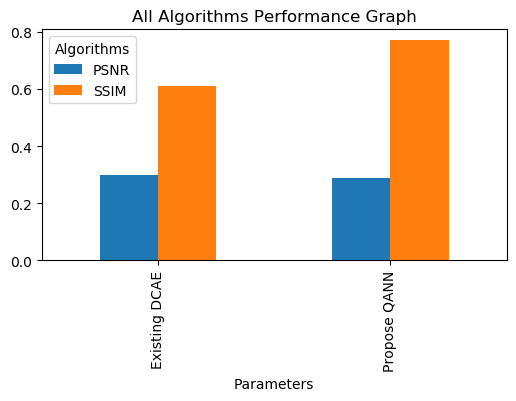

In [40]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Existing DCAE','SSIM',dcae_ssim_value],['Existing DCAE','PSNR',dcae_psnr],
                   ['Propose QANN','SSIM',qann_ssim_value],['Propose QANN','PSNR',qann_psnr],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [62]:
#function to decompress image using QANN model
def decodeCompressImage(path):
    original = cv2.imread(path) #reading original image
    original = cv2.resize(original, (128, 128), cv2.INTER_LANCZOS4)
    test = QANN.getQANNFeatures(path, qann)#get QANN features
    temp = []
    temp.append(test)
    test = np.asarray(temp)
    test = test.astype('float32')
    test = test/255
    predict = qann_model.predict(test)#applying qann classical model on qann features to decompress image 
    predict = predict[0]#get predicted decompress image
    figure, axis = plt.subplots(nrows=1, ncols=2,figsize=(6,3))#visualize images
    axis[0].set_title("Original Image")
    axis[1].set_title("QANN Decompressed Image")
    axis[0].imshow(original)
    axis[1].imshow(predict)
    figure.tight_layout()
    plt.show()  

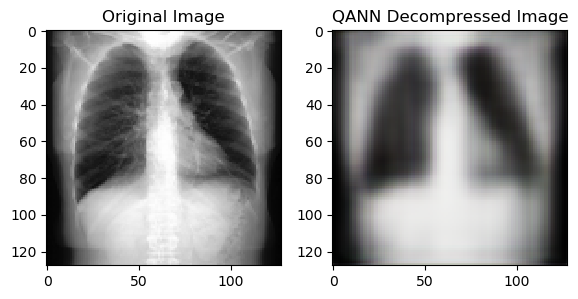

In [63]:
#call this function to get QANN features on test image and then input to QANN model to get decompress image
decodeCompressImage("testImages/1.png")

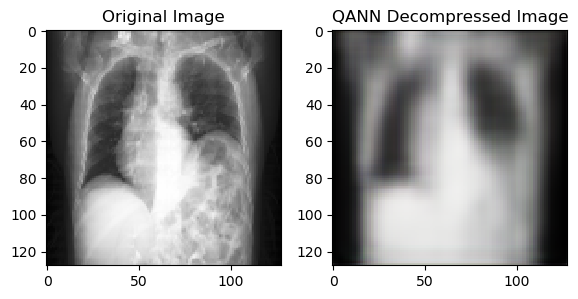

In [65]:
#call this function to get QANN features on test image and then input to QANN model to get decompress image
decodeCompressImage("testImages/3.png")

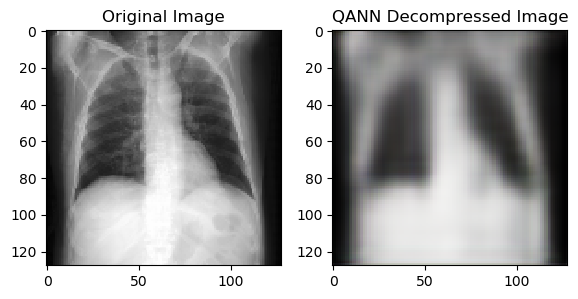

In [66]:
#call this function to get QANN features on test image and then input to QANN model to get decompress image
decodeCompressImage("testImages/4.png")